In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Reproducibility
RANDOM_STATE = 42

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)
print("sklearn:", __import__("sklearn").__version__)
print("seaborn:", sns.__version__)

pandas : 3.0.6
numpy  : 2.5.3
sklearn: 1.9.1
seaborn: 0.13.2


In [2]:
DATA_PATH = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
df.describe(include="object").T

C:\Users\Admin\AppData\Local\Temp\ipykernel_23120\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [6]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing if len(missing) else "None ✅")

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

Columns with missing values:
None ✅

Duplicate rows: 0


In [7]:
print(df["Attrition"].value_counts())
print()
print(df["Attrition"].value_counts(normalize=True).round(4) * 100, "%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64 %


In [8]:
# Show unique values for low-cardinality categorical columns
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"{col:30s} -> {df[col].nunique():3d} unique  |  {df[col].unique()[:6]}")

Attrition                      ->   2 unique  |  <StringArray>
['Yes', 'No']
Length: 2, dtype: str
BusinessTravel                 ->   3 unique  |  <StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str
Department                     ->   3 unique  |  <StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str
EducationField                 ->   6 unique  |  <StringArray>
['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
Length: 6, dtype: str
Gender                         ->   2 unique  |  <StringArray>
['Female', 'Male']
Length: 2, dtype: str
JobRole                        ->   9 unique  |  <StringArray>
['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager']
Length: 6, dtype: str
MaritalStatus                  ->   3 unique  |  <StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str
Over18 

C:\Users\Admin\AppData\Local\Temp\ipykernel_23120\3468232506.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


In [9]:
# Columns with only one unique value (constant)
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns:", constant_cols)

# Columns with only a single unique value's worth of information
for col in constant_cols:
    print(f"  {col}: {df[col].unique()}")

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount: [1]
  Over18: <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours: [80]


In [10]:
DROP_COLS = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]

df_clean = df.drop(columns=DROP_COLS).copy()
print("Dropped:", DROP_COLS)
print("New shape:", df_clean.shape)   # expect (1470, 31)

Dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)


In [11]:
# Yes -> 1, No -> 0
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})
print(df_clean["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


In [12]:
print("Missing values total:", df_clean.isnull().sum().sum())
print("Duplicate rows      :", df_clean.duplicated().sum())
print("Final shape         :", df_clean.shape)

Missing values total: 0
Duplicate rows      : 0
Final shape         : (1470, 31)


In [13]:
cat_cols = df_clean.select_dtypes(include="str").columns.tolist()
num_cols = df_clean.select_dtypes(include="number").columns.tolist()

print(f"Categorical ({len(cat_cols)}): {cat_cols}\n")
print(f"Numeric     ({len(num_cols)}): {num_cols}")

Categorical (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numeric     (24): ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the visualizations folder exists relative to the notebook
VIZ_DIR = Path("../visualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, dpi=120):
    """Save the current figure to visualizations/<name>.png"""
    out = VIZ_DIR / f"{name}.png"
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"Saved -> {out}")

# Consistent palette for Attrition (0=No, 1=Yes)
ATTR_PALETTE = {0: "#4C9F70", 1: "#D7263D"}   # green = stayed, red = left

Saved -> ..\visualizations\01_target_balance.png


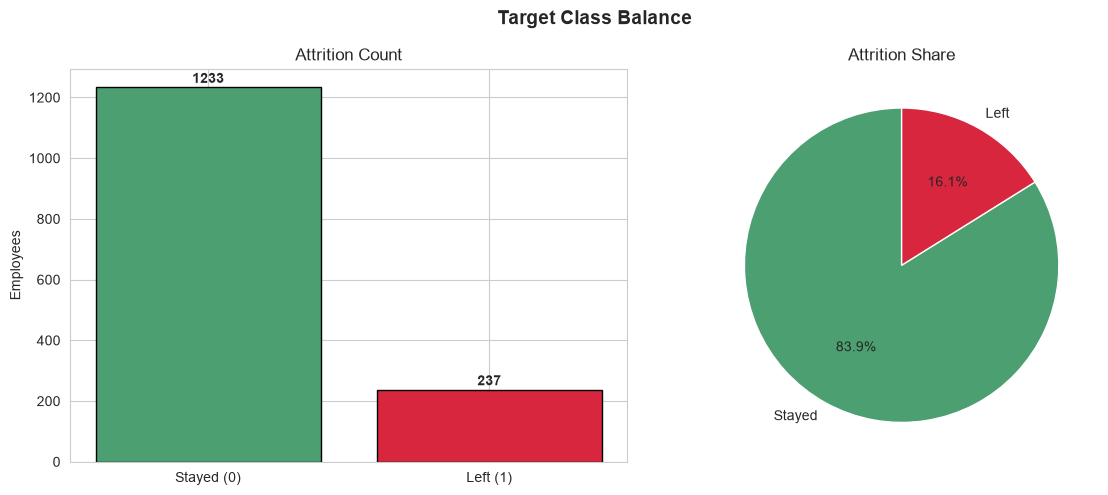

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
counts = df_clean["Attrition"].value_counts().sort_index()
axes[0].bar(["Stayed (0)", "Left (1)"], counts.values,
            color=[ATTR_PALETTE[0], ATTR_PALETTE[1]], edgecolor="black")
axes[0].set_title("Attrition Count")
axes[0].set_ylabel("Employees")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha="center", fontweight="bold")

# Pie
axes[1].pie(counts.values, labels=["Stayed", "Left"],
            autopct="%1.1f%%", colors=[ATTR_PALETTE[0], ATTR_PALETTE[1]],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Attrition Share")

plt.suptitle("Target Class Balance", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("01_target_balance")
plt.show()

Saved -> ..\visualizations\02_numeric_distributions.png


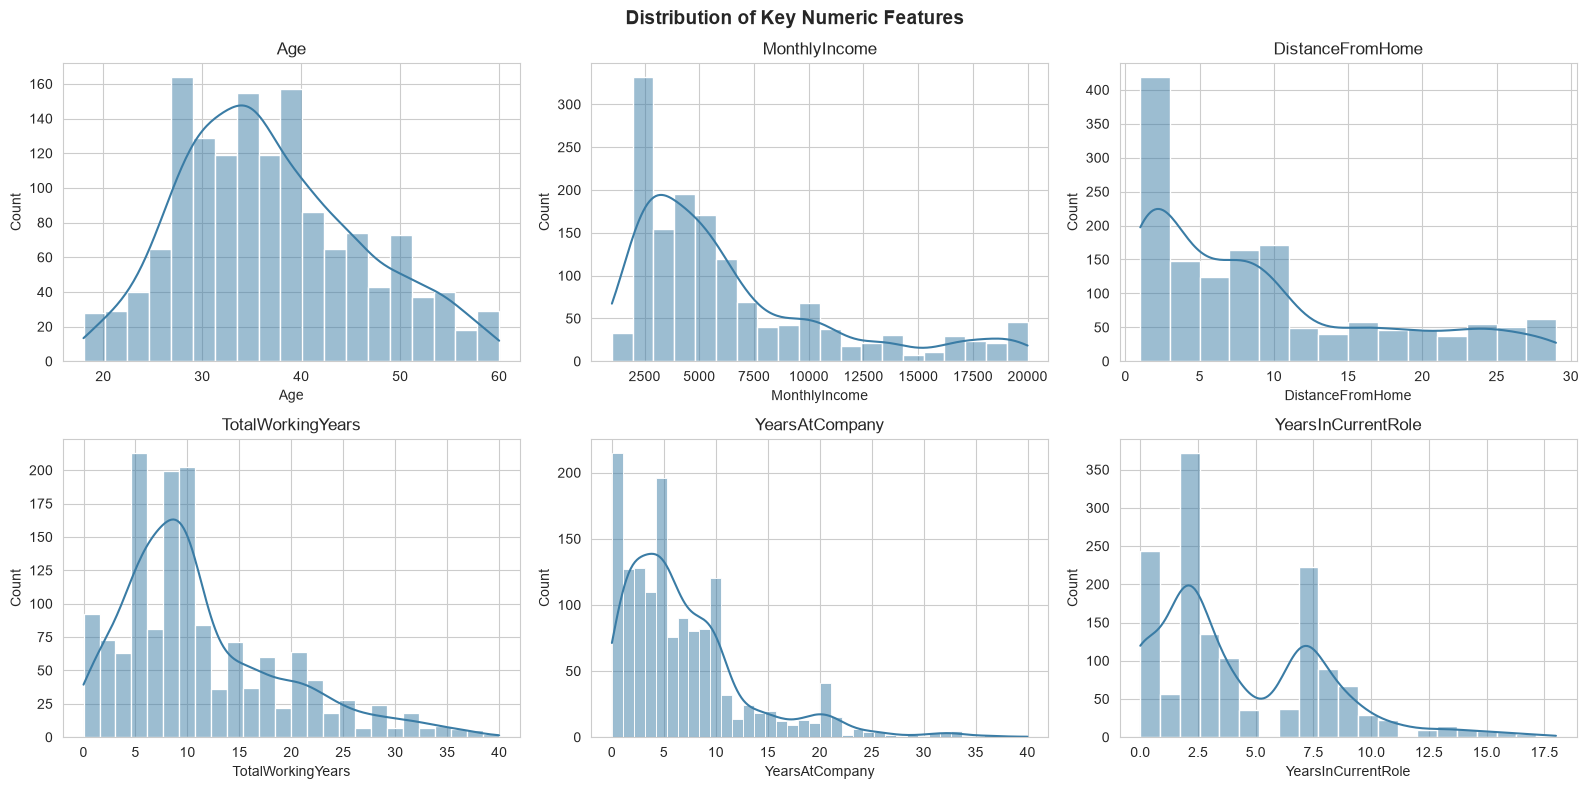

In [19]:
# A subset of the most interesting numeric columns
plot_cols = ["Age", "MonthlyIncome", "DistanceFromHome",
             "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color="#3A7CA5")
    ax.set_title(col)
plt.suptitle("Distribution of Key Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("02_numeric_distributions")
plt.show()

Saved -> ..\visualizations\03_numeric_vs_attrition.png


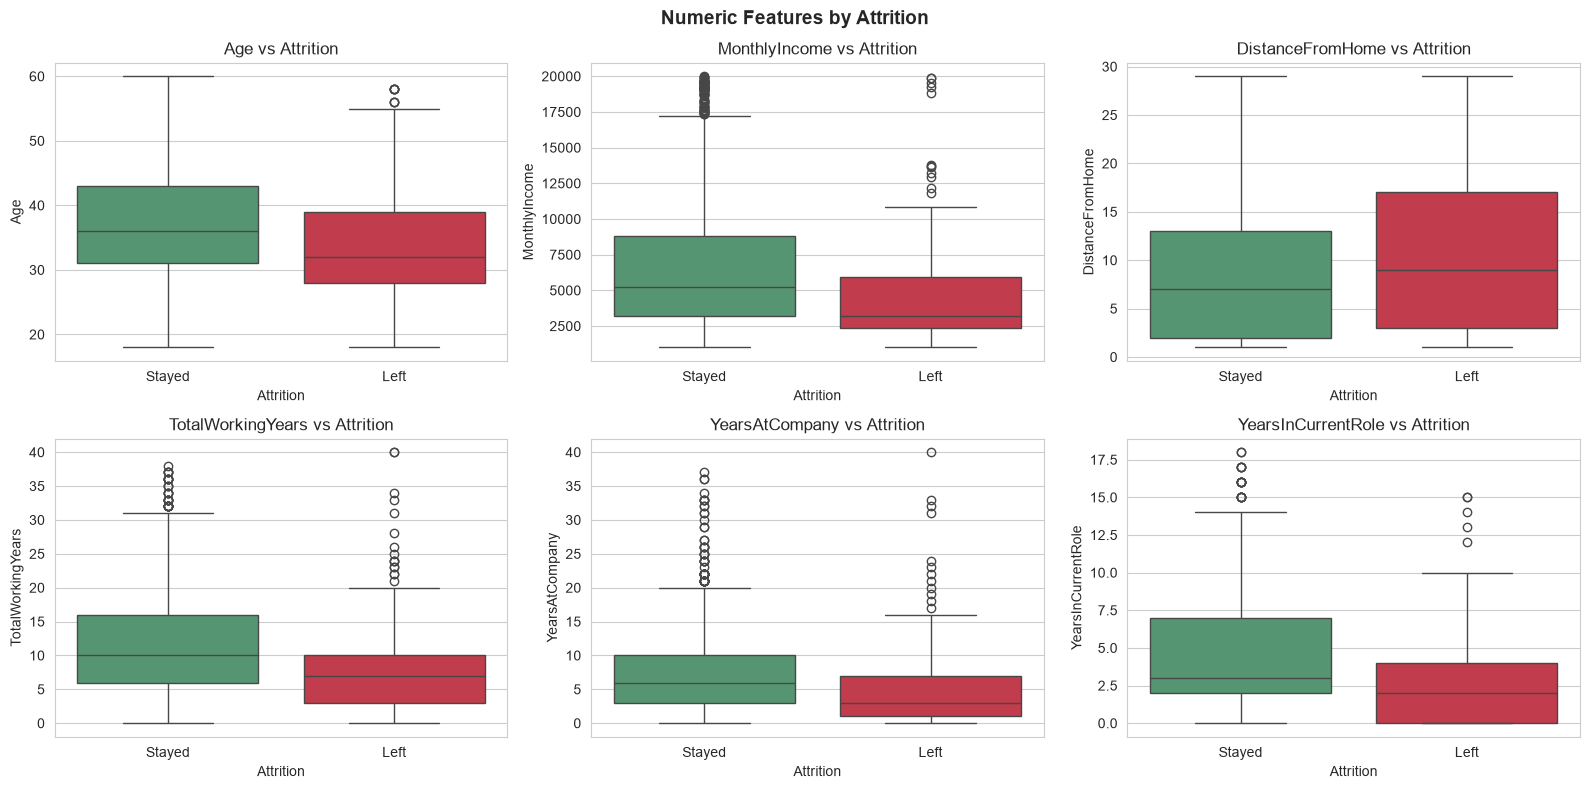

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(
        data=df_clean,
        x="Attrition",
        y=col,
        hue="Attrition",          # ← NEW: required in seaborn 0.13+
        palette=ATTR_PALETTE,
        legend=False,             # we don't need a legend, x-axis is clear
        ax=ax,
    )
    ax.set_title(f"{col} vs Attrition")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Stayed", "Left"])

plt.suptitle("Numeric Features by Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("03_numeric_vs_attrition")
plt.show()

Saved -> ..\visualizations\04_categorical_vs_attrition.png


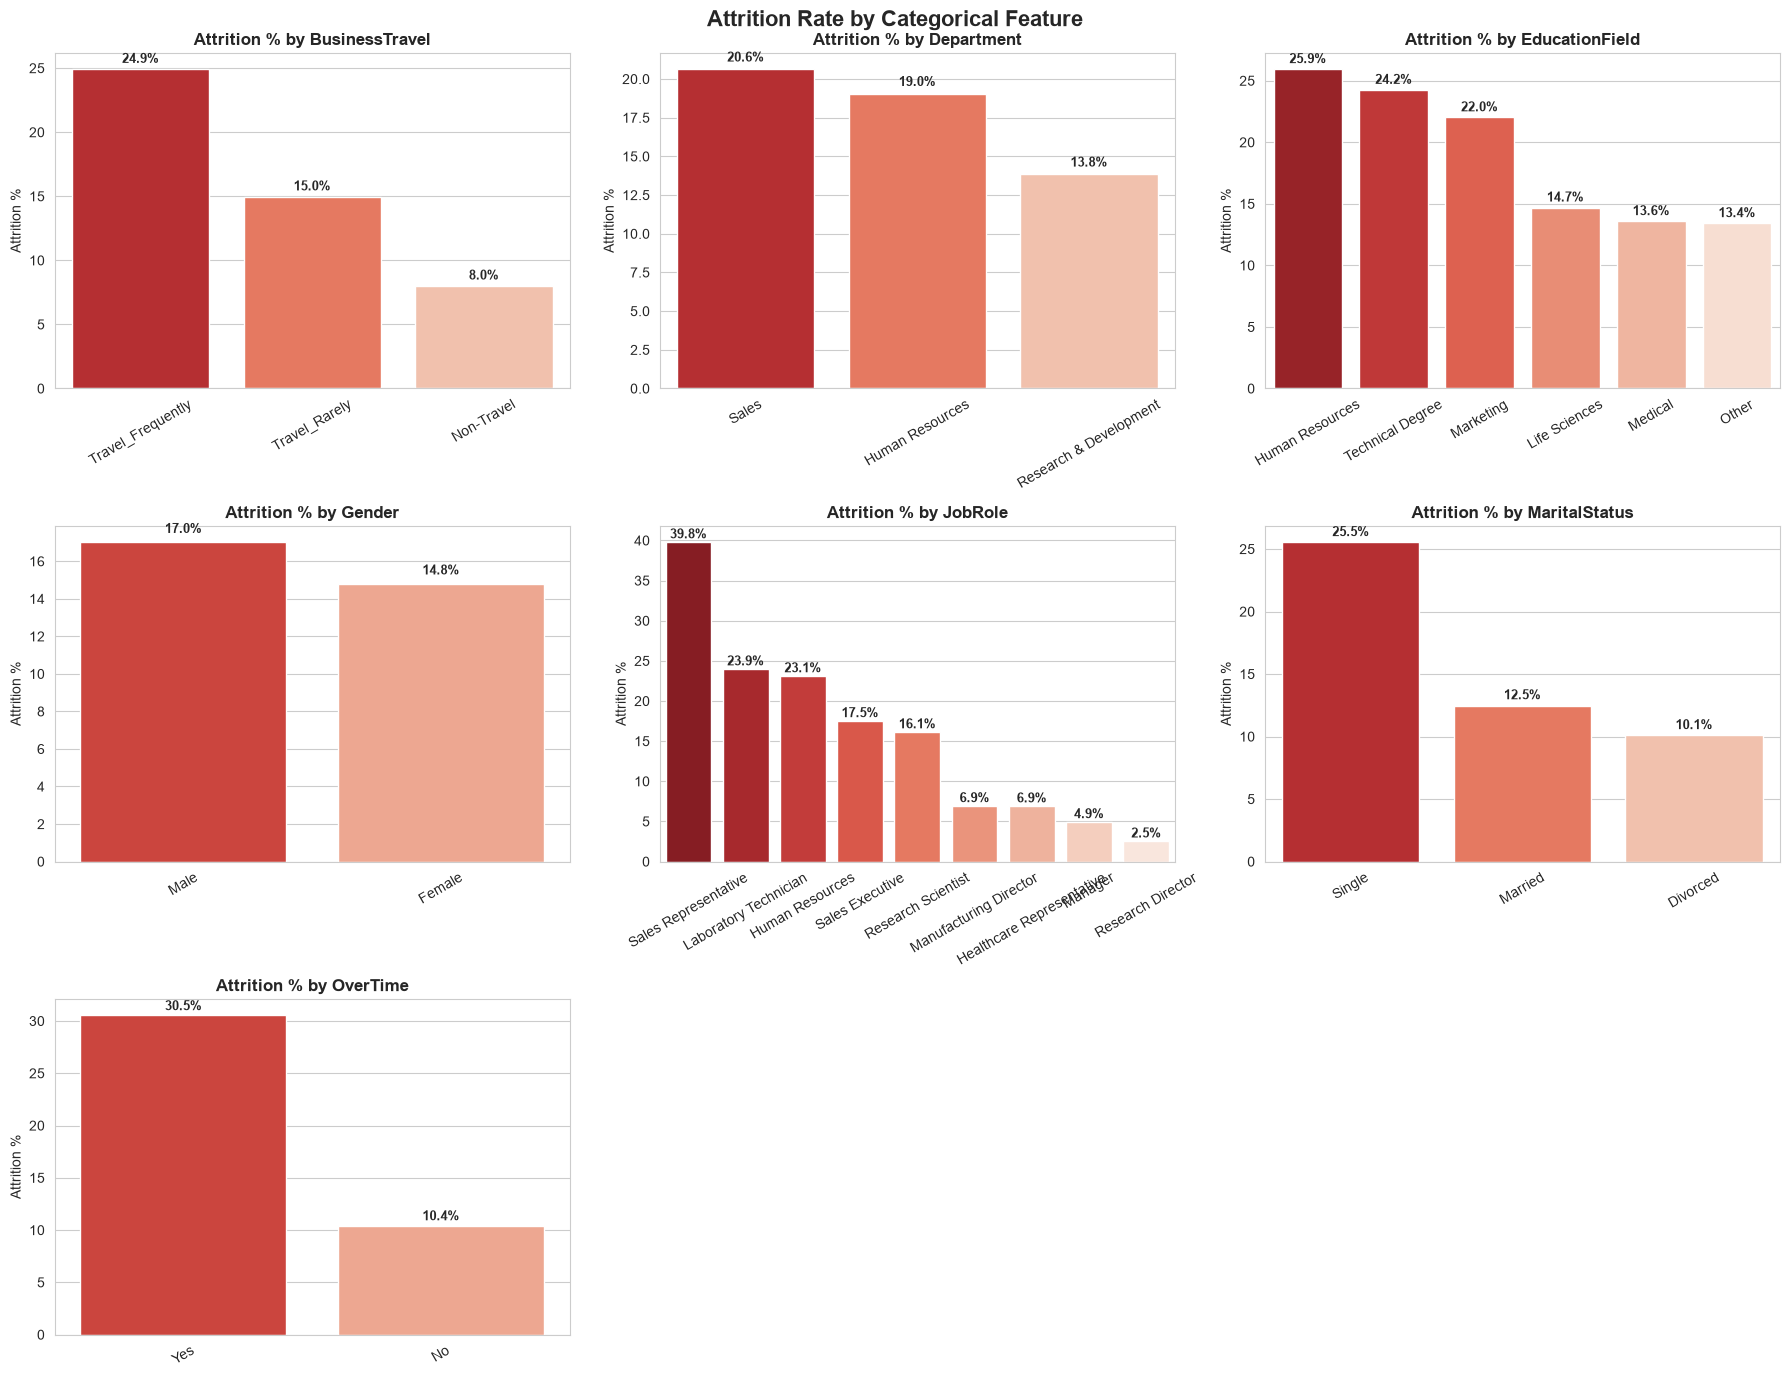

In [22]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    # Compute attrition rate per category
    rates = (df_clean.groupby(col)["Attrition"]
             .agg(["mean", "count"])
             .sort_values("mean", ascending=False))
    rates["attrition_pct"] = rates["mean"] * 100

    sns.barplot(
        data=rates.reset_index(),
        x=col,
        y="attrition_pct",
        hue=col,
        palette="Reds_r",
        legend=False,
        ax=axes[i],
    )
    axes[i].set_title(f"Attrition % by {col}", fontweight="bold")
    axes[i].set_ylabel("Attrition %")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

    # Annotate bars with the % value
    for p, v in zip(axes[i].patches, rates["attrition_pct"].values):
        axes[i].text(p.get_x() + p.get_width()/2, v + 0.5,
                     f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Hide the two unused subplots (7 cats, 9 slots)
for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Attrition Rate by Categorical Feature",
             fontsize=16, fontweight="bold")
plt.tight_layout()
save_fig("04_categorical_vs_attrition")
plt.show()

Saved -> ..\visualizations\05_correlation_heatmap.png


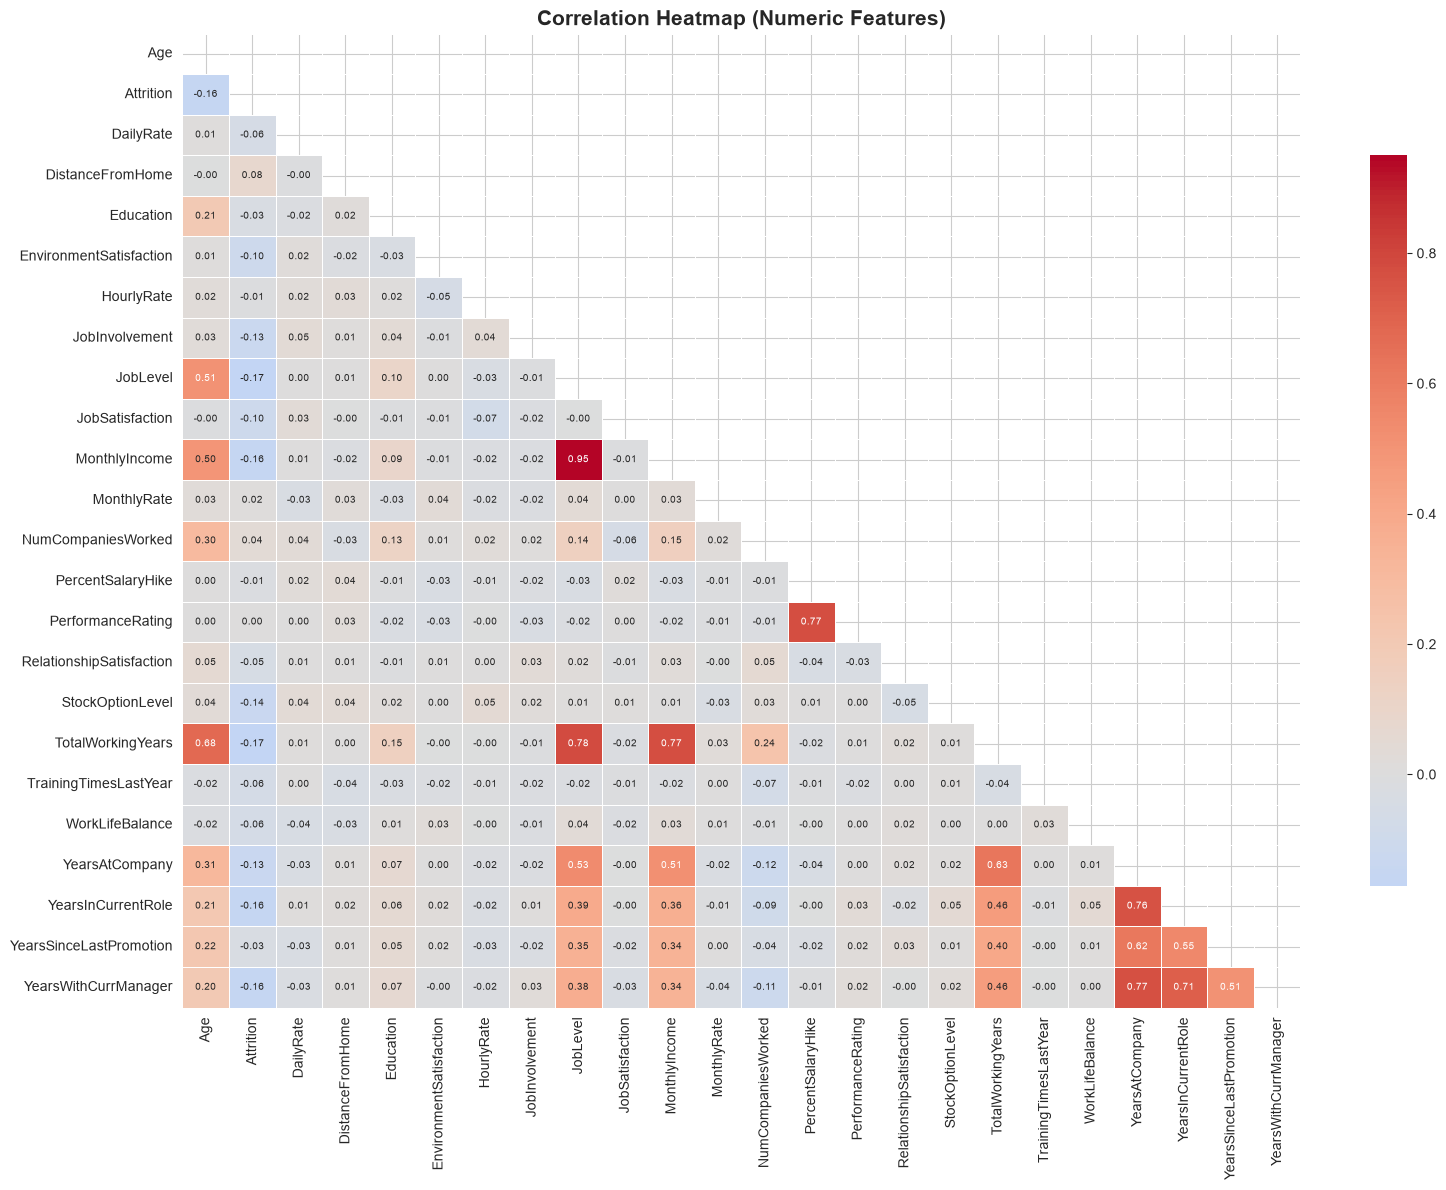

In [23]:
# Compute correlation matrix on numeric columns only
corr = df_clean[num_cols].corr()

# Mask the upper triangle so it's easier to read
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.4,
    cbar_kws={"shrink": 0.75},
    ax=ax,
)
ax.set_title("Correlation Heatmap (Numeric Features)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
save_fig("05_correlation_heatmap")
plt.show()

Saved -> ..\visualizations\06_top_correlations.png


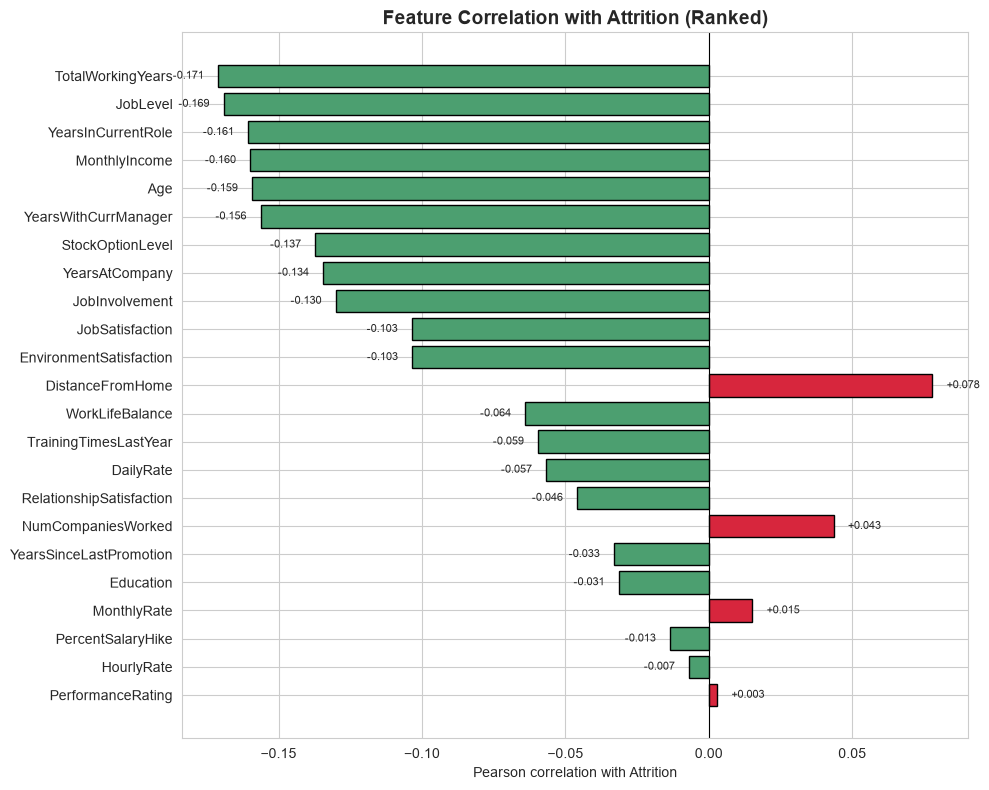


Top 10 features by |correlation| with Attrition:
TotalWorkingYears      -0.1711
JobLevel               -0.1691
YearsInCurrentRole     -0.1605
MonthlyIncome          -0.1598
Age                    -0.1592
YearsWithCurrManager   -0.1562
StockOptionLevel       -0.1371
YearsAtCompany         -0.1344
JobInvolvement         -0.1300
JobSatisfaction        -0.1035
Name: Attrition, dtype: float64


In [24]:
target_corr = (df_clean[num_cols]
               .corr(numeric_only=True)["Attrition"]
               .drop("Attrition")
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#D7263D" if v > 0 else "#4C9F70" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Attrition")
ax.set_title("Feature Correlation with Attrition (Ranked)",
             fontsize=14, fontweight="bold")
for i, (name, v) in enumerate(zip(target_corr.index[::-1],
                                  target_corr.values[::-1])):
    ax.text(v + (0.005 if v >= 0 else -0.005), i,
            f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
save_fig("06_top_correlations")
plt.show()

print("\nTop 10 features by |correlation| with Attrition:")
print(target_corr.head(10).round(4))

In [27]:
# Cell 1 — imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42

In [28]:
# Cell — load the CLEAN file (we already saved it — no need to redo cleaning)
df_clean = pd.read_csv("../data/processed/employees_clean.csv")
print("Loaded clean:", df_clean.shape)
print(df_clean["Attrition"].value_counts())

Loaded clean: (1470, 31)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [29]:
# Cell — re-setup the save helper (in case kernel was restarted)
VIZ_DIR = Path("../visualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name, dpi=120):
    out = VIZ_DIR / f"{name}.png"
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    print(f"Saved -> {out}")

ATTR_PALETTE = {0: "#4C9F70", 1: "#D7263D"}

In [30]:
# Work on a copy so the clean CSV stays pristine
df_fe = df_clean.copy()

# 1. Income per year of experience — captures pay fairness
#    (someone earning 8k with 2 yrs exp is in a different place than 8k with 20 yrs)
df_fe["IncomePerYearWorked"] = (
    df_fe["MonthlyIncome"] / (df_fe["TotalWorkingYears"] + 1)
)

# 2. Tenure ratio — how much of career spent at this company
#    (high ratio → loyal/stable; low ratio → hopper)
df_fe["TenureRatio"] = (
    df_fe["YearsAtCompany"] / (df_fe["TotalWorkingYears"] + 1)
)

# 3. Promotion gap — how long since last promotion relative to tenure
#    (high gap → feeling stuck → attrition)
df_fe["PromotionGapRatio"] = (
    df_fe["YearsSinceLastPromotion"] / (df_fe["YearsAtCompany"] + 1)
)

# 4. Manager stability — how long with current manager relative to tenure
df_fe["ManagerStability"] = (
    df_fe["YearsWithCurrManager"] / (df_fe["YearsAtCompany"] + 1)
)

# Sanity check
new_cols = ["IncomePerYearWorked", "TenureRatio",
            "PromotionGapRatio", "ManagerStability"]
print(df_fe[new_cols].describe().T.round(3))
print("\nNew shape:", df_fe.shape)   # expect (1470, 35)

                      count     mean      std     min      25%      50%      75%       max
IncomePerYearWorked  1470.0  587.575  284.651  95.286  374.232  549.221  738.304  1904.000
TenureRatio          1470.0    0.582    0.284   0.000    0.368    0.636    0.833     0.976
PromotionGapRatio    1470.0    0.236    0.269   0.000    0.000    0.143    0.429     0.917
ManagerStability     1470.0    0.466    0.277   0.000    0.286    0.500    0.667     0.895

New shape: (1470, 35)


ManagerStability      -0.1533
IncomePerYearWorked    0.0977
TenureRatio           -0.0924
PromotionGapRatio      0.0104
Name: Attrition, dtype: float64
Saved -> ..\visualizations\07_engineered_features.png


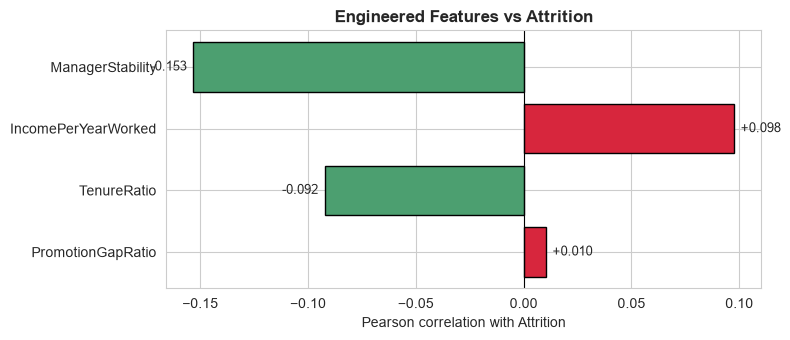

In [31]:
new_corr = (df_fe[new_cols + ["Attrition"]]
            .corr()["Attrition"]
            .drop("Attrition")
            .sort_values(key=abs, ascending=False))
print(new_corr.round(4))

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#D7263D" if v > 0 else "#4C9F70" for v in new_corr.values]
ax.barh(new_corr.index[::-1], new_corr.values[::-1],
        color=colors[::-1], edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Attrition")
ax.set_title("Engineered Features vs Attrition", fontweight="bold")
for i, v in enumerate(new_corr.values[::-1]):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f"{v:+.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
save_fig("07_engineered_features")
plt.show()

In [32]:
# We'll one-hot encode the 7 categorical columns (drop_first avoids
# perfect multicollinearity — standard for linear models)
cat_for_ohe = df_fe.select_dtypes(include="str").columns.tolist()

df_encoded = pd.get_dummies(
    df_fe,
    columns=cat_for_ohe,
    drop_first=True,
    dtype=int,
)

print("Categorical columns one-hot encoded:", cat_for_ohe)
print("New shape:", df_encoded.shape)
print("\nColumn names:")
for i, c in enumerate(df_encoded.columns, 1):
    print(f"  {i:2d}. {c}")

Categorical columns one-hot encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
New shape: (1470, 49)

Column names:
   1. Age
   2. Attrition
   3. DailyRate
   4. DistanceFromHome
   5. Education
   6. EnvironmentSatisfaction
   7. HourlyRate
   8. JobInvolvement
   9. JobLevel
  10. JobSatisfaction
  11. MonthlyIncome
  12. MonthlyRate
  13. NumCompaniesWorked
  14. PercentSalaryHike
  15. PerformanceRating
  16. RelationshipSatisfaction
  17. StockOptionLevel
  18. TotalWorkingYears
  19. TrainingTimesLastYear
  20. WorkLifeBalance
  21. YearsAtCompany
  22. YearsInCurrentRole
  23. YearsSinceLastPromotion
  24. YearsWithCurrManager
  25. IncomePerYearWorked
  26. TenureRatio
  27. PromotionGapRatio
  28. ManagerStability
  29. BusinessTravel_Travel_Frequently
  30. BusinessTravel_Travel_Rarely
  31. Department_Research & Development
  32. Department_Sales
  33. EducationField_Life Sciences
  34. EducationField_Marketing
  3

In [33]:
out_path = Path("../data/processed/employees_features.csv")
df_encoded.to_csv(out_path, index=False)
print("Saved ->", out_path.resolve())
print("Final shape:", df_encoded.shape)

Saved -> C:\Users\Admin\EmployeeAttritionML\data\processed\employees_features.csv
Final shape: (1470, 49)


In [34]:
# PromotionGapRatio has ~zero signal — drop it to reduce noise
DROP_FE = ["PromotionGapRatio"]

df_final = df_encoded.drop(columns=DROP_FE)
print("Dropped:", DROP_FE)
print("Final shape:", df_final.shape)   # expect (1470, 48)

Dropped: ['PromotionGapRatio']
Final shape: (1470, 48)


In [35]:
out_path = Path("../data/processed/employees_features_final.csv")
df_final.to_csv(out_path, index=False)
print("Saved ->", out_path.resolve())
print("Final shape:", df_final.shape)

Saved -> C:\Users\Admin\EmployeeAttritionML\data\processed\employees_features_final.csv
Final shape: (1470, 48)


In [36]:
print("All features (input to the model):\n")
for i, c in enumerate(df_final.columns, 1):
    marker = "  ← TARGET" if c == "Attrition" else ""
    print(f"  {i:2d}. {c}{marker}")

All features (input to the model):

   1. Age
   2. Attrition  ← TARGET
   3. DailyRate
   4. DistanceFromHome
   5. Education
   6. EnvironmentSatisfaction
   7. HourlyRate
   8. JobInvolvement
   9. JobLevel
  10. JobSatisfaction
  11. MonthlyIncome
  12. MonthlyRate
  13. NumCompaniesWorked
  14. PercentSalaryHike
  15. PerformanceRating
  16. RelationshipSatisfaction
  17. StockOptionLevel
  18. TotalWorkingYears
  19. TrainingTimesLastYear
  20. WorkLifeBalance
  21. YearsAtCompany
  22. YearsInCurrentRole
  23. YearsSinceLastPromotion
  24. YearsWithCurrManager
  25. IncomePerYearWorked
  26. TenureRatio
  27. ManagerStability
  28. BusinessTravel_Travel_Frequently
  29. BusinessTravel_Travel_Rarely
  30. Department_Research & Development
  31. Department_Sales
  32. EducationField_Life Sciences
  33. EducationField_Marketing
  34. EducationField_Medical
  35. EducationField_Other
  36. EducationField_Technical Degree
  37. Gender_Male
  38. JobRole_Human Resources
  39. JobRole_

In [38]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=["Attrition"])
y = df_final["Attrition"]

print("X shape:", X.shape)   # (1470, 47)
print("y shape:", y.shape)
print("\nTarget distribution in y:")
print(y.value_counts(normalize=True).round(4))

X shape: (1470, 47)
y shape: (1470,)

Target distribution in y:
Attrition
0    0.8388
1    0.1612
Name: proportion, dtype: float64


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,   # ← keeps ~16% positives in BOTH train and test
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(4))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Train shape: (1176, 47) | Test shape: (294, 47)

Train target distribution:
Attrition
0    0.8384
1    0.1616
Name: proportion, dtype: float64

Test target distribution:
Attrition
0    0.8401
1    0.1599
Name: proportion, dtype: float64


In [40]:
X_train.to_csv("../data/processed/X_train.csv", index=False)
X_test.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)
print("Saved train/test splits.")

Saved train/test splits.


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

print("Models imported ✅")

Models imported ✅


In [42]:
# Logistic Regression needs scaled features → use a Pipeline
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
}

print("Models defined:", list(models.keys()))

Models defined: ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [43]:
import time

results = {}
predictions = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    # Predict class labels AND probabilities
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "TrainTime(s)": round(train_time, 3),
    }
    print(f"  trained in {train_time:.2f}s")

print("\nAll models trained ✅")


=== Training Logistic Regression ===
  trained in 0.08s

=== Training Random Forest ===
  trained in 0.79s

=== Training Gradient Boosting ===
  trained in 1.23s

All models trained ✅


In [44]:
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)

# Format for readability
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print("=== Model Comparison (Test Set) ===")
print(results_df.round(4))

# Save it for the README / portfolio
results_df.round(4).to_csv("../models/model_comparison.csv")
print("\nSaved -> models/model_comparison.csv")

=== Model Comparison (Test Set) ===
                     Accuracy  Precision  Recall     F1  ROC-AUC  TrainTime(s)
Logistic Regression    0.7653     0.3659  0.6383 0.4651   0.8034        0.0770
Gradient Boosting      0.8503     0.5789  0.2340 0.3333   0.8094        1.2340
Random Forest          0.8231     0.3333  0.1064 0.1613   0.7656        0.7880

Saved -> models/model_comparison.csv


Saved -> ..\visualizations\08_model_comparison.png


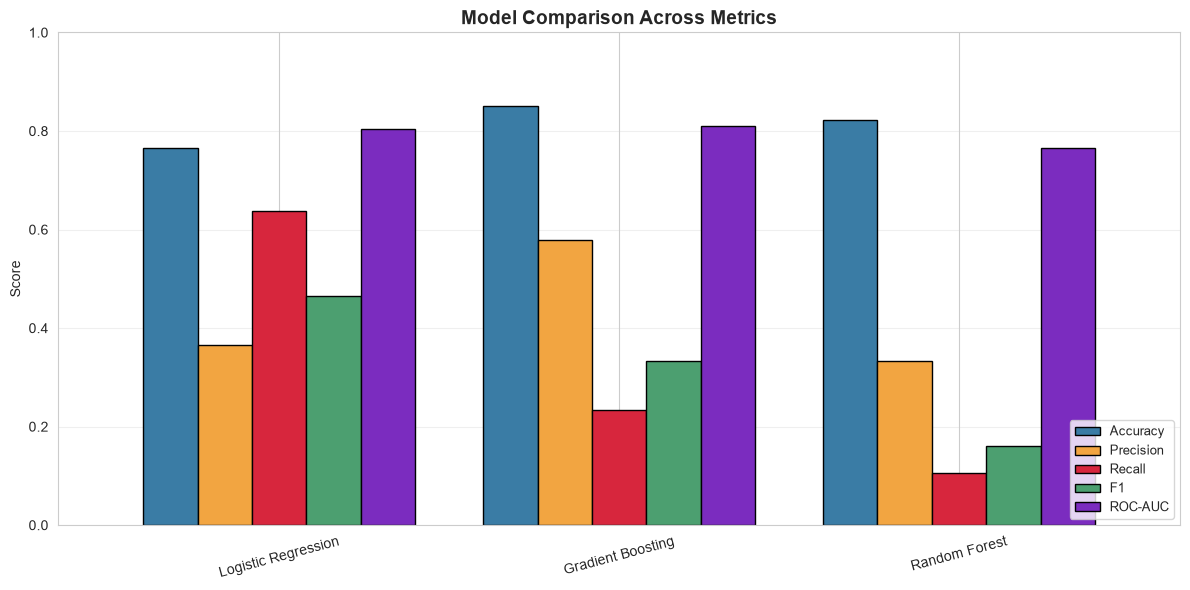

In [45]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(12, 6))
results_df[metrics_to_plot].plot(
    kind="bar", ax=ax, width=0.8,
    color=["#3A7CA5", "#F2A541", "#D7263D", "#4C9F70", "#7B2CBF"],
    edgecolor="black",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison Across Metrics",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
save_fig("08_model_comparison")
plt.show()

Saved -> ..\visualizations\09_confusion_matrices.png


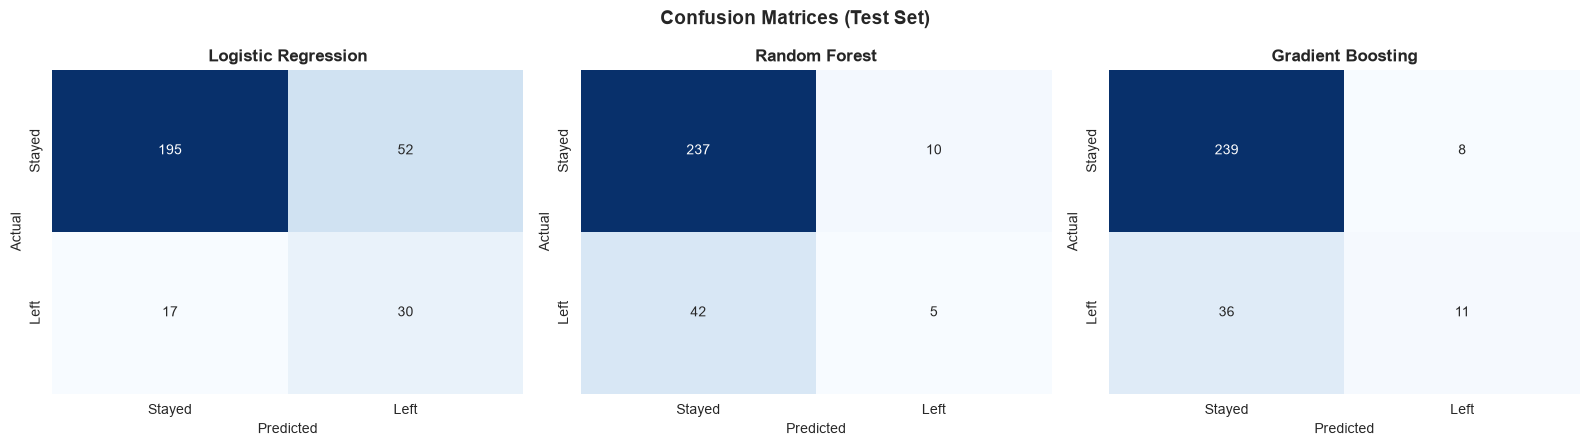

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                cbar=False, ax=ax,
                xticklabels=["Stayed", "Left"],
                yticklabels=["Stayed", "Left"])
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices (Test Set)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("09_confusion_matrices")
plt.show()

In [47]:
best_name = results_df.index[0]
best_pred = predictions[best_name]["y_pred"]

print(f"=== Classification Report — {best_name} ===\n")
print(classification_report(y_test, best_pred,
                            target_names=["Stayed (0)", "Left (1)"],
                            digits=4))

=== Classification Report — Logistic Regression ===

              precision    recall  f1-score   support

  Stayed (0)     0.9198    0.7895    0.8497       247
    Left (1)     0.3659    0.6383    0.4651        47

    accuracy                         0.7653       294
   macro avg     0.6428    0.7139    0.6574       294
weighted avg     0.8313    0.7653    0.7882       294



In [50]:
# SMOTE lives in imblearn — install if missing
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print("imblearn already installed ✅")
except ImportError:
    print("imblearn not installed. Run this in a terminal:")
    print("    pip install imbalanced-learn")
    raise

imblearn already installed ✅


In [51]:
smote_pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

smote_pipe.fit(X_train, y_train)
y_pred_smote  = smote_pipe.predict(X_test)
y_proba_smote = smote_pipe.predict_proba(X_test)[:, 1]

results["Logistic Regression + SMOTE"] = {
    "Accuracy":  accuracy_score(y_test, y_pred_smote),
    "Precision": precision_score(y_test, y_pred_smote, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_smote, zero_division=0),
    "F1":        f1_score(y_test, y_pred_smote, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_proba_smote),
    "TrainTime(s)": None,
}
predictions["Logistic Regression + SMOTE"] = {
    "y_pred": y_pred_smote, "y_proba": y_proba_smote,
}

print("SMOTE LR trained ✅")

SMOTE LR trained ✅


In [52]:
rf_smote_pipe = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
])

rf_smote_pipe.fit(X_train, y_train)
y_pred_rf_smote  = rf_smote_pipe.predict(X_test)
y_proba_rf_smote = rf_smote_pipe.predict_proba(X_test)[:, 1]

results["Random Forest + SMOTE"] = {
    "Accuracy":  accuracy_score(y_test, y_pred_rf_smote),
    "Precision": precision_score(y_test, y_pred_rf_smote, zero_division=0),
    "Recall":    recall_score(y_test, y_pred_rf_smote, zero_division=0),
    "F1":        f1_score(y_test, y_pred_rf_smote, zero_division=0),
    "ROC-AUC":   roc_auc_score(y_test, y_proba_rf_smote),
    "TrainTime(s)": None,
}
predictions["Random Forest + SMOTE"] = {
    "y_pred": y_pred_rf_smote, "y_proba": y_proba_rf_smote,
}

print("SMOTE RF trained ✅")

SMOTE RF trained ✅


In [53]:
results_df = pd.DataFrame(results).T.sort_values("F1", ascending=False)
print("=== Updated Model Comparison ===")
print(results_df.round(4))

results_df.round(4).to_csv("../models/model_comparison.csv")
print("\nSaved -> models/model_comparison.csv")

=== Updated Model Comparison ===
                             Accuracy  Precision  Recall     F1  ROC-AUC  TrainTime(s)
Logistic Regression + SMOTE    0.7857     0.3919  0.6170 0.4793   0.7876           NaN
Logistic Regression            0.7653     0.3659  0.6383 0.4651   0.8034        0.0770
Random Forest + SMOTE          0.8231     0.4242  0.2979 0.3500   0.7371           NaN
Gradient Boosting              0.8503     0.5789  0.2340 0.3333   0.8094        1.2340
Random Forest                  0.8231     0.3333  0.1064 0.1613   0.7656        0.7880

Saved -> models/model_comparison.csv


Saved -> ..\visualizations\10_model_comparison_with_smote.png


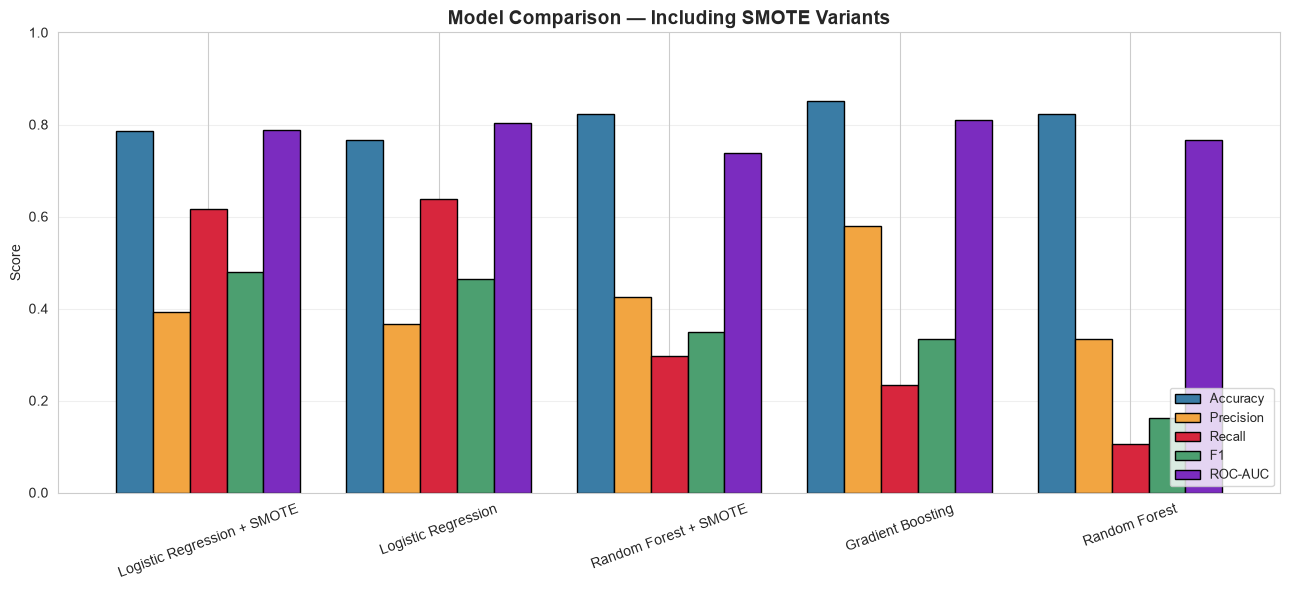

In [54]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

fig, ax = plt.subplots(figsize=(13, 6))
results_df[metrics_to_plot].plot(
    kind="bar", ax=ax, width=0.8,
    color=["#3A7CA5", "#F2A541", "#D7263D", "#4C9F70", "#7B2CBF"],
    edgecolor="black",
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Including SMOTE Variants",
             fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
save_fig("10_model_comparison_with_smote")
plt.show()

In [55]:
import joblib

# Best model by F1
best_name = results_df.index[0]
print(f"🏆 Best model by F1: {best_name}")

# Reassemble the model object for the winner
best_model = {
    "Logistic Regression":         models["Logistic Regression"],
    "Random Forest":               models["Random Forest"],
    "Gradient Boosting":           models["Gradient Boosting"],
    "Logistic Regression + SMOTE": smote_pipe,
    "Random Forest + SMOTE":       rf_smote_pipe,
}[best_name]

# Save with joblib
model_path = Path("../models/attrition_model.joblib")
joblib.dump(best_model, model_path)
print(f"Saved -> {model_path.resolve()}")

# Also save metadata (feature names + best model name) for Django
import json
meta = {
    "model_name": best_name,
    "feature_names": list(X_train.columns),
    "target_map": {"0": "Stayed", "1": "Left"},
    "metrics": results_df.loc[best_name].to_dict(),
}
meta_path = Path("../models/model_metadata.json")
meta_path.write_text(json.dumps(meta, indent=2))
print(f"Saved -> {meta_path.resolve()}")

🏆 Best model by F1: Logistic Regression + SMOTE
Saved -> C:\Users\Admin\EmployeeAttritionML\models\attrition_model.joblib
Saved -> C:\Users\Admin\EmployeeAttritionML\models\model_metadata.json


In [56]:
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
pred  = loaded.predict(sample)[0]
proba = loaded.predict_proba(sample)[0, 1]
actual = y_test.iloc[0]

print(f"Sample prediction: {pred}  (probability of Leaving: {proba:.3f})")
print(f"Actual label    : {actual}")
print(f"Match           : {'✅' if pred == actual else '❌'}")

Sample prediction: 0  (probability of Leaving: 0.290)
Actual label    : 0
Match           : ✅
